# Calculations of cooling tower with Poppe  and Merkel method.Comparision

## Import of libraries

In [1]:
from lib import AirFlow, WaterFlow, PoppeSolver, u, Q_, MerkelSolver
import matplotlib.pyplot as plt

### Play with units
In this project we use PINT behind - library for units. It makes work with units more or less natural. We provide 2 methods - u and Q_

In [2]:
weight = 1*u.kg
double_weight = 2 * weight
even_heavier = double_weight + 500*u.g
print(f"weight = {weight} double it = {double_weight} add gramms = {even_heavier}")

weight = 1 kilogram double it = 2 kilogram add gramms = 2.5 kilogram


In [3]:
#Distance from town A to town B - 500 km, Time = 12h30min what is average velocity. Different types of initialization
distance = Q_(500, u.km)
travel_time = 12*u.hour + Q_(30, u.minute)
velocity = distance / travel_time
print(f"velocity={velocity:.3f}")

velocity=40.000 kilometer / hour


### Work with temperatures
it is different, you can not multiply or add temperatures
Thats why only one way of initialization -> Q_

In [4]:
#work with temperatures
temp = Q_(30, u.degC)
#Convert to Fahrenheit
print(temp.to(u.degF))
temp_cold = Q_(20, u.degC)
#difference
print(temp - temp_cold)

85.99999999999993 degree_Fahrenheit
10 delta_degree_Celsius


In [5]:
try:
    t = temp + temp_cold
except Exception as e:
    print(e)
    print("You can not add temperatures, use delta_degC")

t = temp + Q_(40.0, u.delta_degC)
print(t)
delta_t = Q_(20.0, u.delta_degC) + Q_(30.0, u.delta_degC) + 2.0*u.delta_degF
print(f"You can do math with delta_deg; delta_t = {delta_t}")

Ambiguous operation with offset unit (degree_Celsius, degree_Celsius). See https://pint.readthedocs.io/en/stable/user/nonmult.html for guidance.
You can not add temperatures, use delta_degC
70.0 degree_Celsius
You can do math with delta_deg; delta_t = 51.111111111111114 delta_degree_Celsius


### Density - units like $kg/m^3$

In [6]:
density = 60*u.tonne/(50*u.m**3)
print(density.to(u.pound/u.gallon))

10.014485342423194 pound / gallon


## External formulas

In [7]:
def evaporation_snip(water_in, water_out, air):
    return (0.0009971 + 0.00002357 * (air.temp) - 0.0000002143 * (air.temp)) * (water_in.temp - water_out.temp)

def evaporation_kurita(water_in, water_out, air):
    retutn (0.575 + 0.011 * air.temp) * (water_in.temp - water_out.temp) / 580

I use PINT python library behind the scene so it is possible to use different units

## Input data

In [8]:
#Air 20C, 60% humidity; 1 atm
#Hot water 45C, 1500 ppm TDS
LG_RATIO = 1.2
air = AirFlow(temp=Q_(20, u.degC), humidity=Q_(60, u.perc))
water_in = WaterFlow(temp=Q_(35, u.degC), salinity=Q_(1500, u.mg/u.kg))
water_out = WaterFlow(temp=Q_(25, u.degC), salinity=Q_(1500, u.mg/u.kg))
# Solver object to calculate everything
psolver = PoppeSolver(air, water_in, water_out, lg_ratio=LG_RATIO)
msolver = MerkelSolver(air, water_in, water_out, lg_ratio=LG_RATIO)

## Results

### Merkel number

In [9]:
me_m = msolver.solve()
me_p = psolver.solve()
print(f"NTU by Merkel = {me_m:.3f}, by Poppe = {me_p:.3f}")

NTU by Merkel = 1.256, by Poppe = 1.256


### Calc lg

In [10]:
lg_merkel = msolver.find_operating_lg()
lg_poppe = psolver.find_operating_lg()
print(f"LG calculated by Merkel {lg_merkel} by Poppe {lg_poppe}")

LG calculated by Merkel 0.89747292314042 by Poppe 0.6841910816770421


### Estimate_temperatures with given delta t

Initial data:

T air = 30C, humidity = 40%

C parameter of cooling tower 1.0, n = 0.6

Water flow is 2000 t/h

We need to dissipate from heat_exchanger 20MW of energy.

And we need temperature of cold water less then 25C

Which air flow has to be?

In [11]:
#create water_in and water_out objects, particular values are not important
water_in = WaterFlow(temp=40)
water_out = WaterFlow(temp=30)
#create air according input data
air = AirFlow(temp=30, rh=0.4)
#check wet bulb
print(f"{air.calc_wet_bulb_temperature():.2f}")

20.06 degree_Celsius


In [30]:
#20MW is how many MJ per hour
power = (Q_(20, u.megawatt) * Q_(1, u.hour)).to(u.joule).magnitude
#get water specific heat
cp = water_in.calc_specific_heat().magnitude
water_flow = 2000.0 #t/h
#target delta temp
delta_temp = power/cp/(water_flow*1000.0)
lg_ratio = 1.0
print(f"delta temp = {delta_temp:.2f} water flow = {water_flow:.2f} LG = {lg_ratio:.3f}")

delta temp = 8.60 water flow = 2000.00 LG = 1.000


In [31]:
psolver = PoppeSolver(air_in=air, water_in=water_in,water_out=water_out, lg_ratio=lg_ratio, C=1.0, n=0.6) 

In [32]:
psolver.estimate_temperatures(delta_t=delta_temp)

(36.3384037530683, 27.736458757727686)

In [33]:
#t_cold is too high. decrease lg_ratio
for lg_ratio in [0.5, 0.6, 0.7, 0.8, 0.9]:
    t_hot, t_cold = psolver.estimate_temperatures(delta_t=delta_temp, lg_ratio=lg_ratio)
    print(lg_ratio, t_cold, t_hot)


0.5 24.007835245068616 32.60978024040923
0.6 24.831899290979813 33.43384428632042
0.7 25.612687154192976 34.214632149533585
0.8 26.354497507832722 34.956442503173335
0.9 27.061270292894477 35.66321528823509


with given cooling tower we need LG <=0.6

In [37]:
air_flow_mass = water_flow/lg_ratio
air_flow_volume = air_flow_mass/air.volume_to_dry_mass(1)
print(air_flow_volume, "m3")

2263.6108191982635 m3


### Profiles

Temperature profile (air temperature accross the tower)

Text(0, 0.5, 'Air temp')

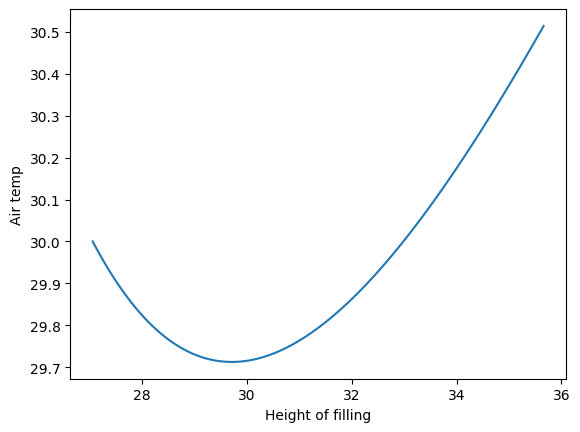

In [45]:
psolver.water_in.temp = 35.66
psolver.water_out.temp=27.06
psolver.lg_ratio = 0.6
me = psolver.solve()
df = psolver.profiles
x = df["water_temp_c"]
y = df["air_temp_c"]
plt.plot(x, y)
plt.xlabel("Height of filling")
plt.ylabel("Air temp")

Humidity of air

Text(0, 0.5, 'Air humidity')

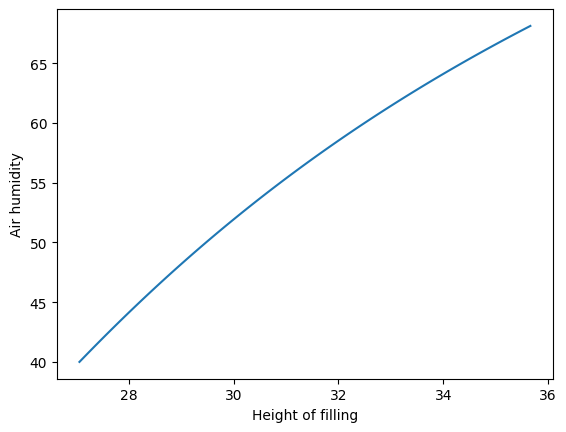

In [47]:
y = df["air_rh_perc"]
plt.plot(x, y)
plt.xlabel("Height of filling")parameterparameter
plt.ylabel("Air humidity")

In [43]:
width = 70
print(f"{'Evaporation (real evaporation + fog drift):':<{width}} {psolver.evaporation*100:>8.2f}%")
print(f"{'Merkel Number:':<{width}} {me:>8.2f}")
print(f"{'Fog drift:':<{width}} {psolver.fog_force*100:>8.2f}%")
print(f"{'Relative parameter to understand which part of filling in a fog area:':<{width}} {psolver.fog_force:>8.2f}%")
print(f"{'Approach:':<{width}} {psolver.water_in.temp - psolver.air_in.wet_bulb_temperature():>8.2f}")

Evaporation (real evaporation + fog drift):                                1.37%
Merkel Number:                                                             0.94
Fog drift:                                                                 0.00%
Relative parameter to understand which part of filling in a fog area:      0.00%
Approach:                                                                 15.60
